# Assignment 6: predict the solar index f10.7 from SDO EUV images

## Due on Sunday 29th March at 23:59
### Submit your jupyter notebook on QMPlus (tab Assessments) with name LAST_NAME_Assignment_6.ipynb

### **The Solar Index F10.7**  

The **F10.7 solar flux** (often written as **F10.7 or F10.7 cm flux**) is a key solar activity index that measures the intensity of radio emissions from the Sun at a wavelength of **10.7 cm (or a frequency of 2800 MHz)**. This radio flux is produced by a combination of thermal radiation from the solar corona and non-thermal emissions from solar magnetic activity.  

### **Why Is F10.7 Important?**  

F10.7 is widely used as a **proxy for solar activity**, particularly for describing variations in the Sun’s ultraviolet (UV) and extreme ultraviolet (EUV) emissions, which directly impact the Earth's **ionosphere, thermosphere, and magnetosphere**. Since direct EUV observations are limited in time and availability, F10.7 serves as a long-term, continuous dataset that correlates well with changes in the upper atmosphere.  

It is used in:  

- **Space Weather Prediction**: Higher F10.7 values indicate increased solar activity, which can lead to stronger ionospheric disturbances affecting radio communications and GPS signals.  
- **Satellite Drag Modeling**: The thermosphere expands during high solar activity, increasing drag on satellites in low Earth orbit (LEO). Models such as **NRLMSISE-00** and **JB2008** use F10.7 to predict atmospheric density variations.  
- **Solar Cycle Studies**: F10.7 follows the **11-year solar cycle**, with values increasing during solar maximum and decreasing during solar minimum.  

### **How Is F10.7 Measured?**  

The F10.7 index has been measured daily since **1947** using ground-based radio telescopes, primarily at the **Dominion Radio Astrophysical Observatory (DRAO) in Canada**. The measurements are expressed in **solar flux units (sfu)**, where **1 sfu = 10⁻²² W/m²/Hz**.  

- **Typical range**: ~70 sfu during solar minimum, ~200+ sfu during solar maximum.  
- **Daily and adjusted values**: The standard F10.7 measurement is taken at local noon, while an adjusted version accounts for variations in Earth-Sun distance.  

### **F10.7 in Machine Learning and Solar Predictions**  

Given its strong correlation with solar EUV output, F10.7 is often used as a target variable in **machine learning models**. Researchers use deep learning techniques, such as **CNNs and ViTs**, to predict future F10.7 values based on solar images (e.g., from NASA's SDO), helping improve space weather forecasting and atmospheric models.  

By accurately predicting F10.7, scientists can better understand the **Sun-Earth system**, mitigate space weather risks, and optimize satellite operations.

# <span style="color:red">Task:</span>

### Predict f10.7 from SDO EUV images. In particular, we are going to use the 304 channel of SDO, for the whole year 2014.
### The training and test data, at daily cadence, is stored in "/data/2014_daily"

### The corresponding target values are in /data/f107_train.csv (the test target is not provided)

The task consists in developing the full pipeline of loading the dataset, splitting in training and validation and train a machine learning model that learns the scalar values of f107 from the corresponding images (on the same day).


## At the end of the notebook:
* create a numpy array with the predictions computed on the test images
* define a filename (string) as a .csv 
* save the predictions on a file called 'filename':

e.g.:

filename='predictions.csv'

np.savetxt('predictions.csv',y_pred)


Finally cut and paste the following cell at the bottom of your notebook: 

In [29]:
#prediction = np.loadtxt(filename)
#y_test = np.loadtxt('f107_test.csv')
# Define the score
#from sklearn.metrics import mean_squared_error
#rmse = np.sqrt(mean_squared_error(y_test, prediction))
#R = np.corrcoef(y_test, prediction)[0,1]
#score = 100*np.min((23.0/rmse,1))
#print(score)

## Hints: images are at 512x512 resolution. You can rescale them to speed up training.

## In case you normalize quantities, remember to un-normalize the prediction before saving it.

## In case the code crashes in an attempt to utilize GPUs, add:

import os

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [30]:
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re
from datetime import datetime

from skimage.io import imread
from skimage.transform import resize

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

SEED = 2003

In [31]:
ROOT_DIR = os.path.dirname(os.path.abspath('__file__'))
TRAIN_IMG_DIR = os.path.join(ROOT_DIR, 'data', '2014_daily' , 'train')
TEST_IMG_DIR = os.path.join(ROOT_DIR, 'data', '2014_daily' , 'test')
TRAIN_LABELS_PATH = os.path.join(ROOT_DIR, 'data', 'f107_train.csv')
PROCESSED_DATA_PATH = os.path.join(ROOT_DIR, 'processed_data')
PREDICTIONS_PATH = os.path.join(ROOT_DIR, 'predictions')

IMG_SIZE = (256, 256)       # image size for resizing

EARLY_STOP_PATIENCE = 5  # Number of epochs with no improvement after which training will be stopped

DROPOUT_RATE = 0.5          # Dropout rate for regularization
VAL_SPLIT = 0.1             # Percentage of training data to use for validation

EPOCHS = 100                 # Number of training epochs
BATCH_SIZE = 32             # Batch size for training
LEARNING_RATE = 1e-4        # Learning rate for the optimizer


Loading and Preproccessing

In [32]:
# Extract the day of year (DOY) from the filename
def extract_doy(filepath):
    name = os.path.splitext(os.path.basename(filepath))[0] # Extract the day of year (DOY) from the filename
    numbers = re.findall(r'\d+', name)  # Extract all numeric sequences from the filename

    for n in numbers:
        if len(n) == 8 and n.startswith('2014'): # Look for an 8-digit number starting with '2014'
            try:
                return datetime.strptime(n, '%Y%m%d').timetuple().tm_yday # Convert the date to day of year (DOY)
            except ValueError:
                pass # if parsing fails, continue to the next number
    return None

# List all image files in the directory, supporting common formats and falling back to all files if no matches
def list_files(directory):
    files = glob.glob(os.path.join(directory, '*.jpg'))
    
    #If no files found with specified extensions, list all files in the directory
    if not files:
        files = [os.path.join(directory, f) for f in os.listdir(directory) 
            if os.path.isfile(os.path.join(directory, f))]
        
    #Return the sorted list of file paths
    return sorted(files)

# Load jpg image, convert to grayscale if needed, and resize to the specified dimensions
def load_image(filepath, img_size=IMG_SIZE):
    img = imread(filepath).astype(np.float32) # Read the image and convert to float32 for processing

    # If the image has multiple channels (e.g., RGB), convert it to grayscale by averaging the channels
    if img.ndim == 3: 
        img = img.mean(axis=-1)

    img = resize(img, img_size, anti_aliasing=True, preserve_range=True) # Resize the image to the specified size
    return img

# Preprocess the training and test images, normalize them, and prepare the labels for training
def preprocess(img_size=IMG_SIZE, train_img_dir=TRAIN_IMG_DIR, test_img_dir=TEST_IMG_DIR, labels_path=TRAIN_LABELS_PATH):
    df = pd.read_csv(labels_path) # Load the training labels from CSV
    train_files = list_files(train_img_dir) # retrieve the list of training image files

    # Create a mapping from DOY to file path for the training images
    doy_to_file = {}
    for f in train_files:
        doy = extract_doy(f)
        if doy is not None:
            doy_to_file[doy] = f
    df['filepath'] = df['Doy'].map(doy_to_file) 
    
    # Check for any missing file paths and raise an error if any are found, listing the DOY values with missing files
    if df['filepath'].isna().any():
        missing = df.loc[df['filepath'].isna(), 'Doy'].tolist()
        raise ValueError(f"Missing image files for DOY values: {missing[:10]}")

    # Load the training images and labels into memory, converting them to numpy arrays 
    print('Loading training images from memory...')
    x_train = np.array([load_image(f, img_size) for f in df['filepath']], dtype=np.float32)
    y_train = np.array(df['f107'], dtype=np.float32)

    # Load the test images into memory, converting them to a numpy arrays
    print('Loading test images from memory...')
    test_files = list_files(test_img_dir)
    x_test = np.array([load_image(f, img_size) for f in test_files], dtype=np.float32)

    # Normalize the images to the range [0, 1] using min-max normalization
    img_min = x_train.min()
    img_scale = x_train.max() - img_min
    x_train = (x_train - img_min) / (img_scale + 1e-8)
    x_test = (x_test - img_min) / (img_scale + 1e-8)

    # Add a channel dimension to the images for compatibility with convolutional neural networks
    x_train = x_train[..., np.newaxis]
    x_test = x_test[..., np.newaxis]

    # Calculate mean and standard deviation and normalise target variable for training
    y_mean, y_std = y_train.mean(), y_train.std()
    y_train_norm = (y_train - y_mean) / (y_std + 1e-8)

    print(f'Train: {x_train.shape}, Test: {x_test.shape}, Train Labels: {y_train_norm.shape}')
    print(f'F10.7 mean: {y_mean:.1f}, std: {y_std:.1f}')

    return x_train, y_train_norm, x_test, y_mean, y_std

#Saved the preprocessed data to disk in a structured format for later use, organized by image size
def save_processed_data(x_train, y_train_norm, x_test, y_mean, y_std, img_size=IMG_SIZE, save_path=PROCESSED_DATA_PATH):
    size_tag = f"{img_size[0]}x{img_size[1]}"
    output_dir = os.path.join(save_path, size_tag)
    
    os.makedirs(output_dir, exist_ok=True)
    np.save(os.path.join(output_dir, 'x_train.npy'), x_train)
    np.save(os.path.join(output_dir, 'y_train_norm.npy'), y_train_norm)
    np.save(os.path.join(output_dir, 'x_test.npy'), x_test)
    np.save(os.path.join(output_dir, 'y_mean.npy'), y_mean)
    np.save(os.path.join(output_dir, 'y_std.npy'), y_std)

Training

In [33]:
def build_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1), dropout_rate=DROPOUT_RATE, learning_rate=LEARNING_RATE):
    model = models.Sequential([
        layers.Input(shape=input_shape), 

        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1) # Output layer for regression
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

def train(x_train, y_train, x_val, y_val, epochs=EPOCHS, batch_size=BATCH_SIZE, early_stop_patience=EARLY_STOP_PATIENCE):
    model = build_model()
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=early_stop_patience, restore_best_weights=True)
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=1)
    return history , model

Validation and Testing

In [34]:
def eval_val(model, x_val, y_val, y_mean, y_std):
    y_val_pred_norm = model.predict(x_val).squeeze()
    y_val_pred = y_val_pred_norm * (y_std + 1e-8) + y_mean
    y_val_true = y_val * (y_std + 1e-8) + y_mean

    rsmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
    r = np.corrcoef(y_val_true, y_val_pred)[0,1]

    print(f'Validation RMSE: {rsmse:.3f}')
    print(f'Validation Correlation: {r:.3f}')

    return y_val_pred, y_val_true, rsmse, r

def pred_test(model, x_test, y_mean, y_std, save_dir=PREDICTIONS_PATH):
    y_test_pred_norm = model.predict(x_test).squeeze()
    y_test_pred = y_test_pred_norm * (y_std + 1e-8) + y_mean
    
    os.makedirs(save_dir, exist_ok=True)

    existing_files = glob.glob(os.path.join(save_dir, f'prediction_*.csv'))
    next_index = len(existing_files) + 1
    filename = os.path.join(save_dir, f'prediction_{next_index}.csv')

    np.savetxt(filename, y_test_pred, delimiter=',')
    print(f'Saved predictions to {filename}')
    print(f'Number of predictions: {len(y_test_pred)}')
    print(f'Prediction range: {y_test_pred.min():.2f} to {y_test_pred.max():.2f}')
    print(f'Prediction mean: {y_test_pred.mean():.2f}')
    return filename

Main

In [35]:
def set_seeds(seed=SEED):
    np.random.seed(seed)
    tf.random.set_seed(seed)

def main(save_processed=False):
    set_seeds()
    x_train, y_train, x_test, y_mean, y_std = preprocess()
    if save_processed:
        save_processed_data(x_train, y_train, x_test, y_mean, y_std)
    x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=VAL_SPLIT, random_state=2003)
    history, model = train(x_train, y_train, x_val, y_val)
    eval_val(model, x_val, y_val, y_mean, y_std)
    filename = pred_test(model, x_test, y_mean, y_std)
    return filename, history

filename, history = main(save_processed=True)

Loading training images from memory...
Loading test images from memory...
Train: (250, 256, 256, 1), Test: (115, 256, 256, 1), Train Labels: (250,)
F10.7 mean: 142.9, std: 26.8
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 312ms/step - loss: 0.9917 - mae: 0.7811 - val_loss: 1.2182 - val_mae: 0.8974
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - loss: 0.9832 - mae: 0.7826 - val_loss: 1.2630 - val_mae: 0.9223
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step - loss: 0.9710 - mae: 0.7742 - val_loss: 1.2562 - val_mae: 0.9192
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 260ms/step - loss: 0.9622 - mae: 0.7690 - val_loss: 1.2365 - val_mae: 0.9092
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - loss: 0.9425 - mae: 0.7629 - val_loss: 1.2219 - val_mae: 0.9023
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - loss: 0.9378 - mae: 0.7559 - val_loss: 1.2204 - val_mae: 0.9031
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
Validation RMSE: 29.625
Validation Correlation: 0.329
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 

Graphs

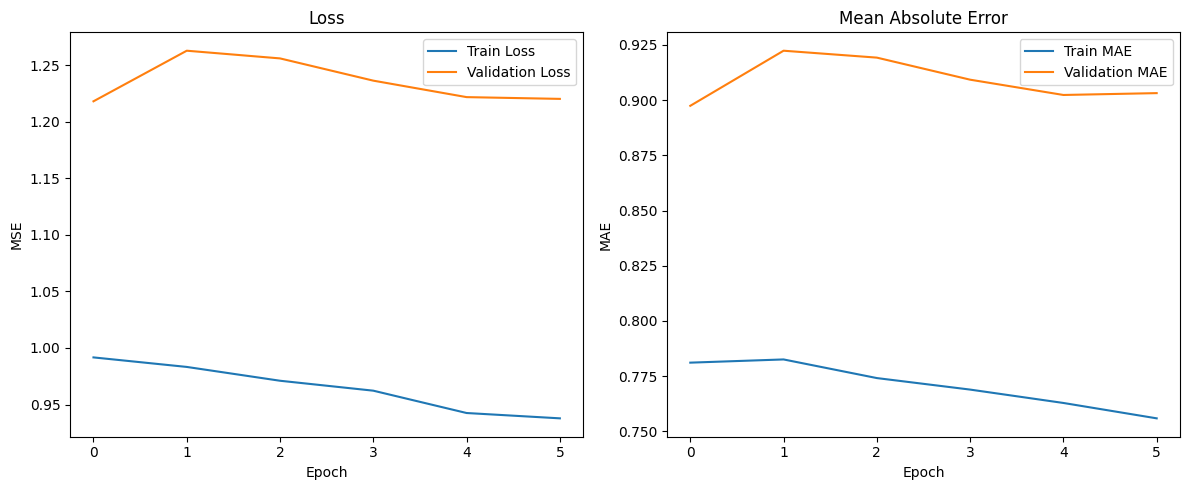

In [36]:
# Plot training and validation loss/MAE from the training history
def plot_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Mean Absolute Error')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()
    
plot_history(history)

Final Test

In [37]:
#prediction = np.loadtxt(filename)
#y_test = np.loadtxt('data/f107_test.csv')
# Define the score
#from sklearn.metrics import mean_squared_error
#rmse = np.sqrt(mean_squared_error(y_test, prediction))
#R = np.corrcoef(y_test, prediction)[0,1]
#score = 100*np.min((23.0/rmse,1))
#print(score)